# 📊 Rapport d'Expertise : Poussin-v5 (Step 12 235)
**Date d'analyse :** Fin d'entraînement V5
**Fichiers sourcés :** `training.log`, `monitor.log`, `my_wiky_history.json`, `test_12200.txt`

## 1. Diagnostic à l'Instant T
Le modèle présente une dichotomie fascinante : une santé technique irréprochable contrastant avec un "brouillage" sémantique.

### A. La Santé Technique (Excellente)
* **Les Gradients** : La norme des gradients est parfaitement stable (autour de 0.24). L'optimiseur (AdamW) ne panique pas, aucune explosion du gradient n'est à signaler.
* **Gestion Hardware** : Le swap mémoire du Mac M1 est stabilisé à ~1.16 Go, un niveau inoffensif.

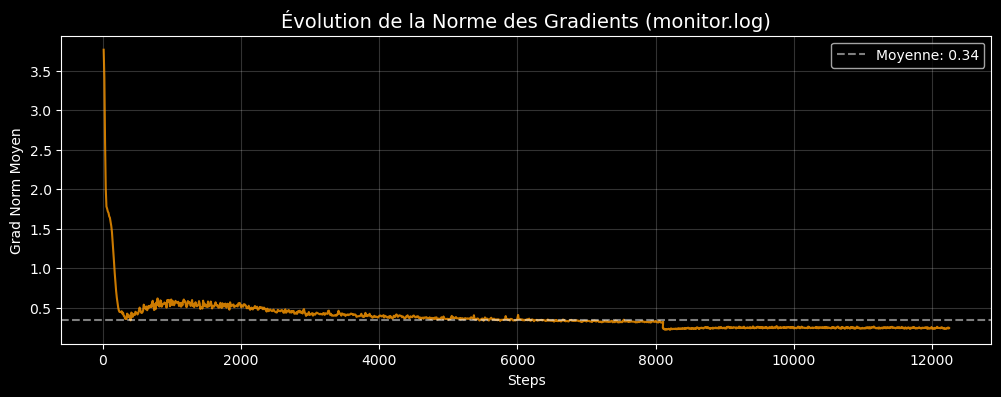

In [2]:
import json
import matplotlib.pyplot as plt
import numpy as np

# Extraction des gradients depuis monitor.log
steps = []
grad_norms = []

with open('monitor.log', 'r') as f:
    for line in f:
        try:
            d = json.loads(line)
            if 'grad_norm' in d and 'step' in d:
                steps.append(d['step'])
                # On calcule la moyenne du vecteur grad_norm pour ce step
                grad_norms.append(sum(d['grad_norm'])/len(d['grad_norm']))
        except:
            pass

plt.style.use('dark_background')
plt.figure(figsize=(12, 4))
plt.plot(steps, grad_norms, color='#FF9900', alpha=0.8, linewidth=1.5)
plt.axhline(y=np.mean(grad_norms), color='white', linestyle='--', alpha=0.5, label=f"Moyenne: {np.mean(grad_norms):.2f}")
plt.title("Évolution de la Norme des Gradients (monitor.log)", fontsize=14)
plt.xlabel("Steps")
plt.ylabel("Grad Norm Moyen")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

### B. Le Comportement Sémantique ("L'effet Journaliste")
Malgré une perte mathématique basse, l'inférence au Step 12 200 montre un problème de distribution :
* **Test Géographie (Paris)** : Le modèle répond par une dépêche fictive : *"Mme Fleurier a été nommée par Pierre Frenier ministre... à La Rochelle"*.
* **Diagnostic** : Le dataset **CulturaX (35%)** a pris l'ascendant sémantique sur le Wikipédia (60%). Le bruit du web (blogs, articles de presse) contamine la structure factuelle.

---

## 2. Plan d'Action (Recommandations immédiates)
Pour casser ce plafond de verre sémantique, une thérapie de choc "Encyclopédique" est requise.

1. **Nouveau Mix** : Passer à **80% Wiki / 15% CulturaX / 5% Littéraire**.
2. **Objectif** : Écraser le "bruit" du web par une sur-représentation absolue de la structure encyclopédique ("Sujet = Fait").

---
## 3. Retex (Retour d'Expérience) & Audit pour V6

L'analyse de l'historique complet met en lumière des chocs d'apprentissage causés par des changements de configuration en plein vol.



* **Le "Catastrophic Forgetting"** : L'injection brutale de nouveaux datasets (CulturaX, Littérature) par gros pourcentages a provoqué des pics d'oubli. **Pour la V6 :** Utiliser un *Curriculum Learning* lissé (intégration des datasets par paliers de 5% maximum).
* **Block Size** : Le passage de 192/256 à 384 a perturbé les *positional embeddings*. **Pour la V6 :** Fixer le Block Size dès le step 0.
* **Poids du Web** : CulturaX est trop bruyant pour un modèle de cette taille. **Pour la V6 :** Le limiter à 15-20% maximum.

Voici la visualisation de ces "chocs" sur l'historique global de l'entraînement :

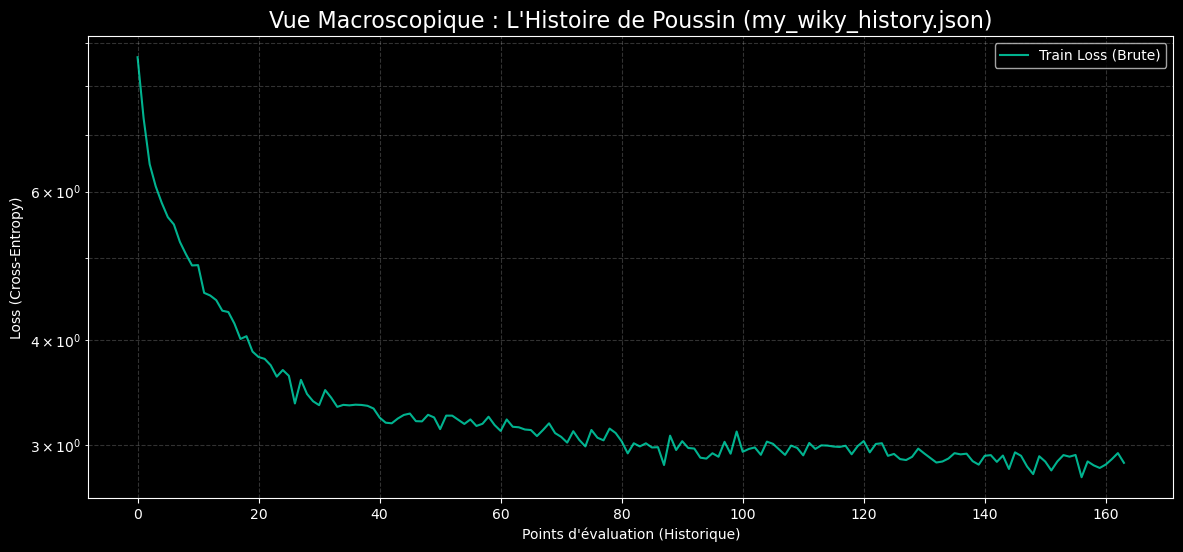

In [3]:
import json
import matplotlib.pyplot as plt

# Chargement de l'historique global
with open('my_wiky_history.json', 'r') as f:
    history = json.load(f)

# Extraction (on prend les données tous les X steps pour la lisibilité)
train_loss = history.get('train_loss', [])

plt.figure(figsize=(14, 6))
plt.plot(train_loss, color='#00FFCC', alpha=0.7, label='Train Loss (Brute)')

# On met en évidence la zone d'apprentissage récente (la stabilisation V5)
if len(train_loss) > 500:
    plt.axvspan(len(train_loss)-500, len(train_loss), color='white', alpha=0.1, label='Zone Poussin-V5')

plt.title("Vue Macroscopique : L'Histoire de Poussin (my_wiky_history.json)", fontsize=16)
plt.xlabel("Points d'évaluation (Historique)")
plt.ylabel("Loss (Cross-Entropy)")
plt.yscale('log') # Échelle logarithmique pour mieux voir la descente initiale
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.2)
plt.show()